In [24]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

In [25]:
def covers_selector(data, attribute, value):
    row = data[attribute].to_numpy()
    if pd.isnull(value):
        return pd.isnull(row)
    return row == value
def covers_subgroup(data, pattern):
    return np.all([covers_selector(data,sel[0],sel[1]) for sel in pattern] , axis=0)

### CARGAR DATASET Y FILTRADO POR TIPO DE CANCER (EN ESTE CASO PULMON)

In [26]:
df = pd.read_csv(f"./pulmon_final.csv",index_col=0)
class_name = "Class"
# Mapeo de valor de clase: Mortalidad -> 1, Incidencia -> 2
df[class_name] = 2
df = df.astype(str)

### DEFINIR EL SUBGRUPO/POBLACION A ANALIZAR

In [27]:
# DEFINIMOS EL SUBGRUPO SOBRE EL QUE QUEREMOS OBTENER INFORMACION Y OBTENEMOS LAS FILAS CORRESPONDIENTES
pattern_description = "Niquel(Ni)==(3.22, 5.74] AND Particulas(PM2.5)> 12.59"
parts = re.split(r'\s+AND\s+', pattern_description)
pattern = r'\s*(.*?)\s*(==|>=|<=|>|<)\s*(.*)\s*'
result = []
for p in parts:
    left, op, right = re.match(pattern, p).groups()
    # regla: si es == no lo mostramos, pero mantenemos valor tal cual
    if op == "==":
        result.append((left, right))
    else:
        result.append((left, f"{op} {right}"))

# Obtenemos las filas correspondientes al subgrupo
ic = covers_subgroup(df,result)
data_filter_subgroup = df.loc[ic]

In [28]:
data_filter_subgroup

,Tasa cruda,Arsenico(As),Cadmio(Cd),Niquel(Ni),Particulas(PM2.5),Plomo(Pb),temp_media_anual,temp_max_abs,temp_min_abs,precipitacion_total,dias_lluvia,noches_tropicales,RentaNeta,Class,CCAA,Grupo de edad,Sexo,Anio_Inicio
450,"(35.04, 68.81]",> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,> 15.36,> 39.05,> -5.73,> 379.06,> 63.25,> 0.44,> 27025.50,2,2,0,3,2023
451,"(68.81, 131.43]",> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,> 15.36,> 39.05,> -5.73,> 379.06,> 63.25,> 0.44,> 27025.50,2,2,0,3,2023
452,<= 0.31,> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,> 15.36,> 39.05,> -5.73,> 379.06,> 63.25,> 0.44,> 27025.50,2,2,1,3,2023
453,<= 0.31,> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,> 15.36,> 39.05,> -5.73,> 379.06,> 63.25,> 0.44,> 27025.50,2,2,2,3,2023
454,<= 0.31,> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,> 15.36,> 39.05,> -5.73,> 379.06,> 63.25,> 0.44,> 27025.50,2,2,2,3,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14781,"(0.31, 1.92]",> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,<= 15.36,<= 39.05,<= -5.73,<= 379.06,> 63.25,> 0.44,> 27025.50,2,5,4,2,2011
14782,"(13.50, 35.04]",> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,<= 15.36,<= 39.05,<= -5.73,<= 379.06,> 63.25,> 0.44,> 27025.50,2,5,5,2,2011
14783,"(13.50, 35.04]",> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,<= 15.36,<= 39.05,<= -5.73,<= 379.06,> 63.25,> 0.44,> 27025.50,2,5,5,2,2011
14784,"(13.50, 35.04]",> 0.20,<= 0.56,"(3.22, 5.74]",> 12.59,<= 0.01,<= 15.36,<= 39.05,<= -5.73,<= 379.06,> 63.25,> 0.44,> 27025.50,2,5,6,2,2011


### VARIABLES SOBRE LAS QUE QUEREMOS OBTENER INFORMACION

In [ ]:
vars_to_search_info = ["Niquel(Ni)", "Arsenico(As)", "Particulas(PM2.5)", "Cadmio(Cd)", "Plomo(Pb)", "Sexo", "temp_media_anual"]

### HACEMOS LA CONSULTA DE LA VARIABLE o VARIABLES PARA VER DESCRIPTIVO

In [30]:
vc = data_filter_subgroup[vars_to_search_info].value_counts()
vc

Arsenico(As)  Cadmio(Cd)  Plomo(Pb)  Sexo  temp_media_anual  CCAA  dias_lluvia  noches_tropicales
> 0.20        <= 0.56     <= 0.01    2     > 15.36           6     > 63.25      > 0.44               96
                                     3     > 15.36           7     <= 63.25     > 0.44               96
                                                             6     > 63.25      > 0.44               96
                                     1     > 15.36           6     > 63.25      > 0.44               96
                                                             7     <= 63.25     > 0.44               96
                                     2     > 15.36           7     <= 63.25     > 0.44               96
                                     3     > 15.36           7     > 63.25      > 0.44               72
                                     1     <= 15.36          6     <= 63.25     > 0.44               72
                                           > 15.36           7     > 6

In [31]:
df_var = data_filter_subgroup[vars_to_search_info]

total = len(df_var)

print(total)

for col in df_var.columns:
    pct = df_var[col].value_counts(normalize=True).mul(100).round(2)
    print(pct)
    print("\n")

1304
Arsenico(As)
> 0.20    100.0
Name: proportion, dtype: float64


Cadmio(Cd)
<= 0.56    100.0
Name: proportion, dtype: float64


Plomo(Pb)
<= 0.01    100.0
Name: proportion, dtype: float64


Sexo
3    33.59
1    33.21
2    33.21
Name: proportion, dtype: float64


temp_media_anual
> 15.36     66.87
<= 15.36    33.13
Name: proportion, dtype: float64


CCAA
6    44.17
7    38.65
5    11.04
2     6.13
Name: proportion, dtype: float64


dias_lluvia
> 63.25     55.83
<= 63.25    44.17
Name: proportion, dtype: float64


noches_tropicales
> 0.44    100.0
Name: proportion, dtype: float64




In [32]:
""" # PODEMOS DEFINIR SI AGRUPAR VALORES DE LA VARIABLE CONSULTADA Y OBTENER FILAS CORRESPONDIENTES A REQUERIMIENTO
values = list(set(vc.index.tolist()) - set(['(0.28, 0.4]']))
df_filtrado = data_filter_subgroup[data_filter_subgroup[vars_to_search_info[0]].isin(values)] """

" # PODEMOS DEFINIR SI AGRUPAR VALORES DE LA VARIABLE CONSULTADA Y OBTENER FILAS CORRESPONDIENTES A REQUERIMIENTO\nvalues = list(set(vc.index.tolist()) - set(['(0.28, 0.4]']))\ndf_filtrado = data_filter_subgroup[data_filter_subgroup[vars_to_search_info[0]].isin(values)] "

## TreeMap: importancia de cada variable

--> Orden por peso: ['Arsenico(As)', 'noches_tropicales', 'Cadmio(Cd)', 'Plomo(Pb)', 'temp_media_anual', 'CCAA', 'dias_lluvia', 'Sexo']
--> Variable dominante: Arsenico(As)



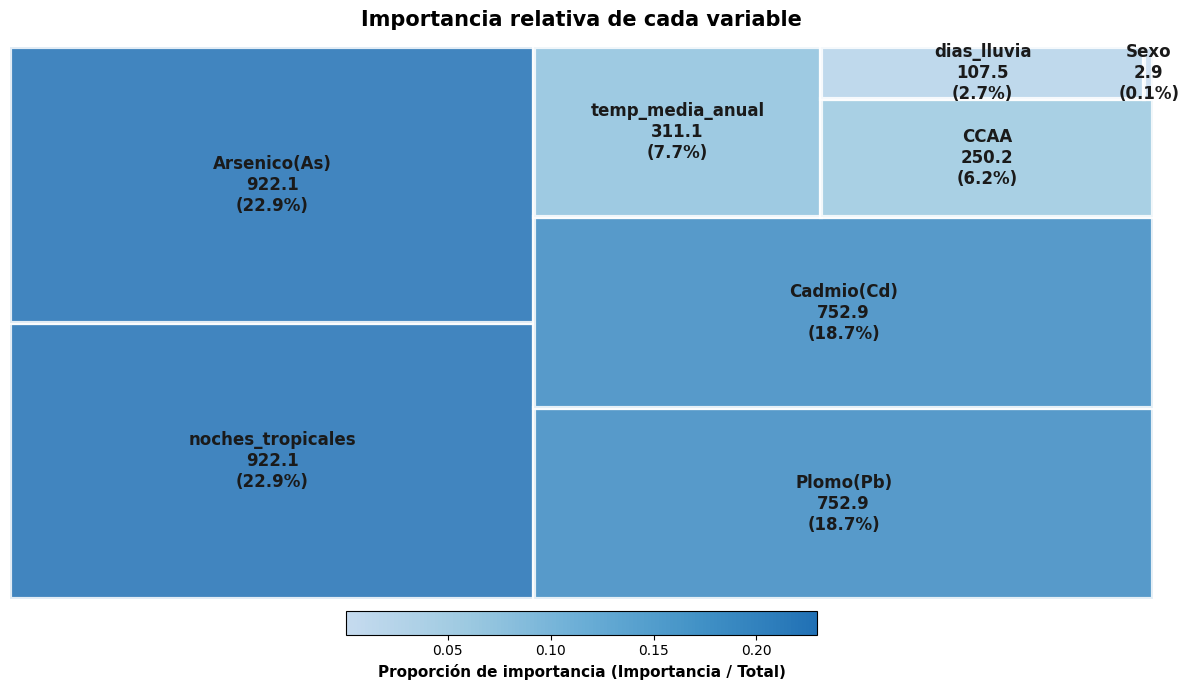

In [33]:
import squarify
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Peso de cada variable
peso_var = {}
for var in vars_to_search_info:
    # Valor de cada variable
    conteo_var = data_filter_subgroup[var].value_counts()
    
    # Mayor desviación = la variable crea grupos más grandes y pesados frente a otros mas pequeños
    if len(conteo_var) > 1:
        peso_var[var] = conteo_var.std()
    else:
        # Si solo hay una categoría, se calcula la desviación típica máxima que tendría si el resto de categorias
        # en el dataset original tuvieran el valor de 0
        k = df[var].nunique()
        if k > 1:
            peso_var[var] = conteo_var.sum() / (k ** 0.5)
        else:
            peso_var[var] = 0.0


# Ordenamos las variables de mayor a menor "peso"
vars_ordenadas = sorted(peso_var, key=peso_var.get, reverse=True)
var_principal = vars_ordenadas[0]


print(f"--> Orden por peso: {vars_ordenadas}")
print(f"--> Variable dominante: {var_principal}\n")

# Importancia total
total_importancia = sum(peso_var.values())

# Preparamos las listas de datos (tamaño = importancia / importancia_total)
nombres = list(peso_var.keys())
pesos = list(peso_var.values())
if total_importancia == 0:
    tamanos = [1.0 / len(pesos) for _ in pesos]
else:
    tamanos = [peso / total_importancia for peso in pesos]
pcts = [tamano * 100 for tamano in tamanos]

# Ordenamos de mayor a menor "peso" para un mejor layout
datos_ordenados = sorted(zip(tamanos, nombres, pcts, pesos), reverse=True)
datos_filtrados = [d for d in datos_ordenados if d[0] > 0]

# Si por algún motivo todos los datos filtrados se borran (todas las importancias son 0)
# forzamos a que sean todas iguales para poder dibujarlas
if not datos_filtrados:
    num_vars = len(datos_ordenados)
    datos_filtrados = [(1.0/num_vars, d[1], 100.0/num_vars, d[3]) for d in datos_ordenados]

# Desempaquetamos los datos ya limpios y seguros
tamanos_ord, nombres_ord, pcts_ord, pesos_ord = zip(*datos_filtrados)

# Colores (degradado)
norm = mcolors.Normalize(vmin=min(tamanos_ord), vmax=max(tamanos_ord))
cmap_base = plt.cm.Blues
cmap = mcolors.LinearSegmentedColormap.from_list('trunc_Blues', cmap_base(np.linspace(0.25, 0.75, 256)))

# Colores al array final
colors = [cmap(norm(tamano)) for tamano in tamanos_ord]

# Etiquetas
labels = []
for nombre, peso, pct in zip(nombres_ord, pesos_ord, pcts_ord):
    texto = f"{nombre}\n{peso:.1f}\n({pct:.1f}%)"
    labels.append(texto)

# Treemap
fig, ax = plt.subplots(figsize=(12, 7))

squarify.plot(
    sizes=tamanos_ord,
    label=labels,
    color=colors,
    alpha=0.85,
    text_kwargs={
        "fontsize": 12,
        "fontweight": "bold",
        "color": "#1A1A1A",
        "wrap": True
    },
    edgecolor="white",   
    linewidth=3,         
    ax=ax
)

# Título
ax.set_title(
    "Importancia relativa de cada variable",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.axis("off")

# Leyenda visual
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.04, pad=0.02)
cbar.set_label("Proporción de importancia (Importancia / Total)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

### TREEMAP (COLOR RECTANGULO SE BASE EN FRECUENCIA DE APARICION == Nº TOTAL DE REGISTROS PARA ESE TIPO)

C:\Users\juanm\AppData\Local\Temp\ipykernel_8024\3086013544.py:126: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


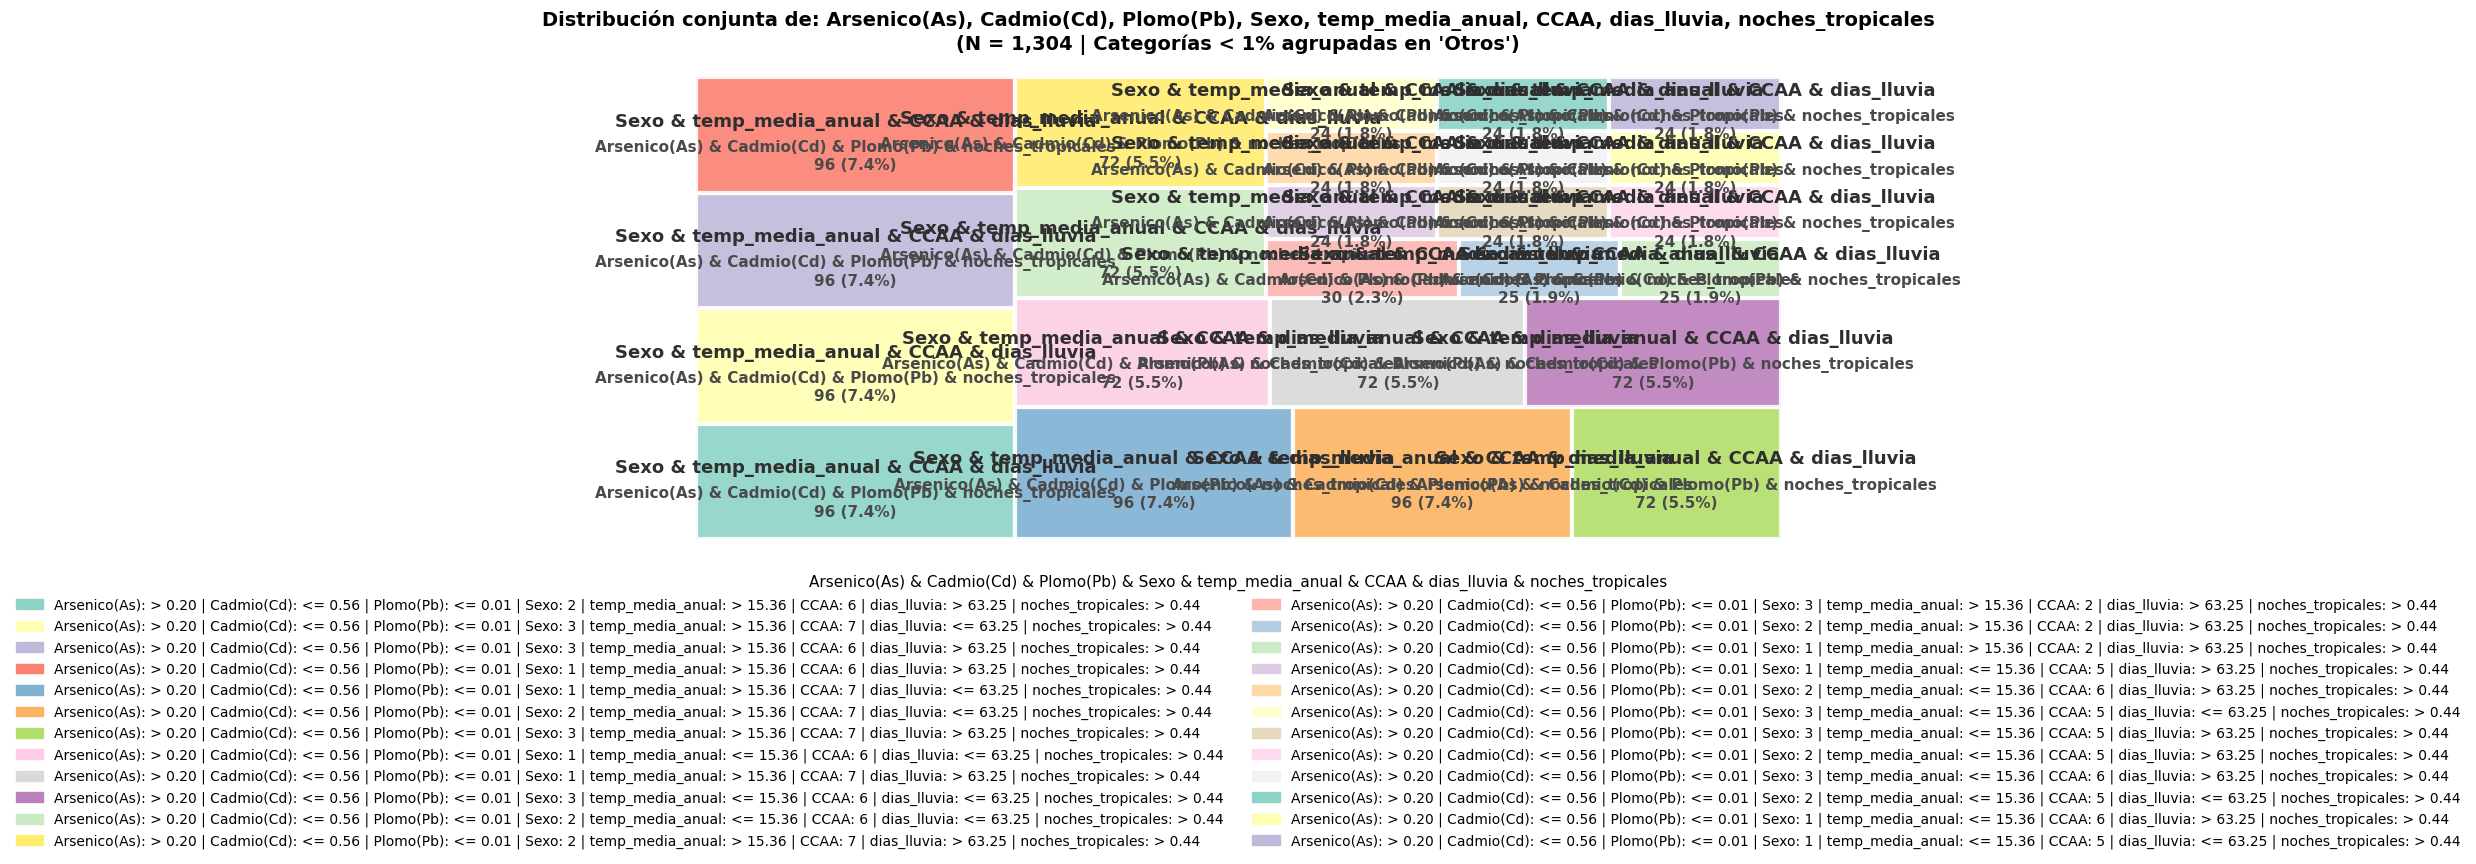

In [34]:
import squarify
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Datos
vc = data_filter_subgroup[vars_to_search_info].value_counts()

# Filtrar categorías muy pequeñas
threshold = vc.sum() * 0.01
vc_filtered = vc[vc >= threshold].copy() # copy() para evitar warnings
other_sum = vc[vc < threshold].sum()

# Manejar de forma dinámica la etiqueta "Otros"
if other_sum > 0:
    if isinstance(vc.index[0], tuple):
        otros_key = tuple(["Otros"] * len(vars_to_search_info))
    else:
        otros_key = "Otros"
    vc_filtered[otros_key] = other_sum

total = vc_filtered.sum()
pcts = (vc_filtered.values / total * 100)


# Detectar de forma automática qué variables cambian y cuáles son constantes
changing_vars = []
constant_vars = []

if isinstance(vc_filtered.index[0], tuple):
    for i, var in enumerate(vars_to_search_info):
        # Extraer valores únicos de esta variable (ignorando la caja "Otros")
        unique_vals = set(idx[i] for idx in vc_filtered.index if not (isinstance(idx, tuple) and idx[0] == "Otros"))
        
        if len(unique_vals) > 1:
            changing_vars.append(var)
        else:
            constant_vars.append(var)
else:
    # Si solo hay 1 variable en el análisis, por definición es la que cambia
    changing_vars = [vars_to_search_info[0]]

# Unir los nombres si hay varios
changing_str = " & ".join(changing_vars) if changing_vars else " & ".join(vars_to_search_info)
constant_str = " & ".join(constant_vars) if constant_vars else ""

# Formatear etiquetas de la leyenda (los valores de cada combinación)
legend_labels = []
for idx in vc_filtered.index:
    if isinstance(idx, tuple):
        name_leg = " | ".join([f"{var}: {v}" for var, v in zip(vars_to_search_info, idx)])
    else:
        name_leg = f"{vars_to_search_info[0]}: {idx}"
    legend_labels.append(name_leg)


# Colores
base_colors = plt.cm.Set3.colors + plt.cm.Pastel1.colors
colors = [base_colors[i % len(base_colors)] for i in range(len(vc_filtered))]


# Crear el gráfico
fig, ax = plt.subplots(figsize=(14, 6)) 

# Cuadrados
squarify.plot(
    sizes=vc_filtered.values,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=3,         
    ax=ax
)

# Textos
for rect, val, pct in zip(ax.patches, vc_filtered.values, pcts):
    # Coordenadas del rectángulo
    x, y, w, h = rect.get_x(), rect.get_y(), rect.get_width(), rect.get_height()
    
    # Coordenadas del centro
    center_x = x + w / 2
    center_y = y + h / 2
    
    if constant_str:
        # Texto principal (la variable que cambia) en grande
        ax.text(center_x, center_y + 1, changing_str, ha='center', va='bottom', 
                fontsize=13, fontweight='bold', color='#2F2F2F', wrap=True)
        
        # Texto secundario (la variable constante + números) en pequeño
        ax.text(center_x, center_y - 1, f"{constant_str}\n{val:,} ({pct:.1f}%)", ha='center', va='top', 
                fontsize=11, fontweight='bold', color='#4A4A4A', wrap=True)
    else:
        # Si no hay variables constantes (todas cambian), lo mostramos todo en tamaño grande
        text_all = f"{changing_str}\n{val:,} ({pct:.1f}%)"
        ax.text(center_x, center_y, text_all, ha='center', va='center', 
                fontsize=14, fontweight='bold', color='#2F2F2F', wrap=True)


# Título principal
ax.set_title(
    f"Distribución conjunta de: {', '.join(vars_to_search_info)}\n"
    f"(N = {total:,} | Categorías < 1% agrupadas en 'Otros')",
    fontsize=14,
    fontweight="bold",
    pad=20
)
ax.axis("off")


# Leyenda
legend_handles = [
    mpatches.Patch(color=colors[i], label=legend_labels[i]) 
    for i in range(len(colors))
]

ax.legend(
    handles=legend_handles, 
    title=" & ".join(vars_to_search_info),
    bbox_to_anchor=(0.5, -0.05),
    loc="upper center",          
    ncol=2,                      
    fontsize=10, 
    title_fontsize=11,
    frameon=False
)

plt.tight_layout()
plt.show()